# 🫒 Détection des Maladies de l'Olivier — Deep Learning

---

| Informations | Détails |
|---|---|
| **Encadrant** | M. Abdallah Khemais |
| **Notebook** | 2 / 6 — Preprocessing & Data Augmentation |
| **Dataset** | Zeytin_224x224_Augmented (Kaggle) |
| **Modèle cible** | EfficientNetB4 |

---

## 🎯 Objectif de ce Notebook

Ce deuxième notebook prépare les données pour l'entraînement :
1. ✅ Chargement de la configuration depuis `config.json`
2. ✅ **Normalisation** des pixels (0–255 → 0–1)
3. ✅ **Split** Train / Validation / Test (70% / 15% / 15%)
4. ✅ **Data Augmentation** : flip, rotation, zoom, brightness, contrast
5. ✅ Visualisation des images **avant vs après** augmentation
6. ✅ Construction du **pipeline tf.data** optimisé GPU
7. ✅ Vérification du pipeline avec un batch de test

---

## 🔑 Concepts clés abordés

| Concept | Rôle |
|---|---|
| **Normalisation** | Ramène les pixels entre 0 et 1 → convergence plus rapide |
| **Data Augmentation** | Crée artificiellement de nouvelles images → réduit l'overfitting |
| **Train/Val/Test Split** | Évalue honnêtement les performances du modèle |
| **tf.data Pipeline** | Charge les images en parallèle → entraînement plus rapide |

In [60]:
!find /kaggle/input/ -name "config.json"

/kaggle/input/notebooks/ahmedboudriga/nb1-setup-exploration/config.json


---
## 📦 Cellule 1 — Import des Librairies

> **Explication :** On réimporte toutes les librairies nécessaires pour ce notebook.
> C'est une bonne pratique de rendre chaque notebook **autonome et exécutable indépendamment**.

In [61]:
# ============================================================
# Cellule 1 — Import des Librairies
# Chaque notebook est autonome : on réimporte tout le nécessaire
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import os
import json
import warnings
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration générale
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

print('Librairies importées avec succès !')
print(f'  TensorFlow : {tf.__version__}')
print(f'  GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

Librairies importées avec succès !
  TensorFlow : 2.19.0
  GPU dispo  : True


---
##  Cellule 2 — Chargement de la Configuration

> **Explication :** On charge le fichier `config.json` créé dans le Notebook 1.
> Cela permet de centraliser tous les paramètres du projet en un seul endroit.
> Si le fichier n'existe pas, on définit des valeurs par défaut.
>
> **Bonne pratique :** ne jamais mettre les chemins et hyperparamètres en dur dans le code !

In [62]:
# ============================================================
# Cellule 2 — Chargement de la Configuration
# On charge config.json du NB1 ou on définit des valeurs par défaut
# ============================================================

CONFIG_PATH = '/kaggle/input/notebooks/ahmedboudriga/nb1-setup-exploration/config.json'

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
        config = json.load(f)
    print('Configuration chargée depuis config.json')
else:
    # Valeurs par défaut si config.json n'existe pas (NB1 non exécuté)
    print('config.json introuvable → utilisation des valeurs par défaut')
    config = {
        'dataset_path'  : '/kaggle/input/zeytin',
        'classes'       : ['aculus_olearius', 'healthy', 'peacock_spot'],
        'num_classes'   : 3,
        'total_images'  : 6961,
        'img_size'      : 224,
        'batch_size'    : 32,
        'epochs'        : 30,
        'learning_rate' : 1e-4,
        'train_split'   : 0.70,
        'val_split'     : 0.15,
        'test_split'    : 0.15,
        'output_dir'    : '/kaggle/working/',
        'model_save_path': '/kaggle/working/olive_efficientnetb4_best.h5',
    }

# Variables globales utilisées dans tout le notebook
DATASET_PATH = config['dataset_path']
IMG_SIZE     = config['img_size']       # 224
BATCH_SIZE   = config['batch_size']     # 32
NUM_CLASSES  = config['num_classes']    # 3
CLASSES      = config['classes']
OUTPUT_DIR   = config['output_dir']

print(f'\n  Dataset path : {DATASET_PATH}')
print(f'  Classes      : {CLASSES}')
print(f'  Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Num classes  : {NUM_CLASSES}')

Configuration chargée depuis config.json

  Dataset path : /kaggle/input/datasets/hikmetdurmaz/zeytin-yaprak-224-aug/Zeytin_224x224_Augmented/val
  Classes      : ['Kus_Gozu_Mantari', 'Pas_Akari', 'Saglikli']
  Image size   : 224x224
  Batch size   : 32
  Num classes  : 3


---
##  Cellule 3 — Construction des listes de fichiers

> **Explication :** On collecte tous les chemins d'images avec leurs labels correspondants.
> - Chaque image reçoit un **label numérique** (0, 1, 2) correspondant à sa classe
> - On crée un DataFrame pandas pour avoir une vue claire de toutes les données
> - Cette structure facilitera le split et le chargement des données

In [63]:
# ============================================================
# Cellule 3 — Construction des listes de fichiers
# On collecte tous les chemins d'images + leurs labels
# ============================================================

all_paths  = []  # Chemins complets vers chaque image
all_labels = []  # Labels numériques (0, 1, 2)
all_names  = []  # Noms des classes (pour affichage)

# Lecture de chaque classe = un sous-dossier du dataset
class_to_idx = {}  # Mapping nom_classe → index numérique
for idx, cls_name in enumerate(sorted(os.listdir(DATASET_PATH))):
    cls_dir = os.path.join(DATASET_PATH, cls_name)
    if not os.path.isdir(cls_dir):
        continue
    class_to_idx[cls_name] = idx
    imgs = [
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    for img_name in imgs:
        all_paths.append(os.path.join(cls_dir, img_name))
        all_labels.append(idx)
        all_names.append(cls_name)

# Mapping inverse : index → nom de classe
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Sauvegarde du mapping dans config
config['class_to_idx'] = class_to_idx
config['idx_to_class'] = idx_to_class

# Création d'un DataFrame récapitulatif
df = pd.DataFrame({
    'path'       : all_paths,
    'label'      : all_labels,
    'class_name' : all_names
})

print(f'Total images collectées : {len(df):,}')
print(f'\nMapping classes → indices :')
for cls, idx in class_to_idx.items():
    print(f'  {idx} --> {cls}')
print(f'\nAperçu du DataFrame :')
print(df.head(6))
print(f'\nDistribution :')
print(df['class_name'].value_counts())

Total images collectées : 980

Mapping classes → indices :
  0 --> Kus_Gozu_Mantari
  1 --> Pas_Akari
  2 --> Saglikli

Aperçu du DataFrame :
                                                path  label        class_name
0  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari
1  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari
2  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari
3  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari
4  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari
5  /kaggle/input/datasets/hikmetdurmaz/zeytin-yap...      0  Kus_Gozu_Mantari

Distribution :
class_name
Kus_Gozu_Mantari    460
Pas_Akari           290
Saglikli            230
Name: count, dtype: int64


---
##  Cellule 4 — Split Train / Validation / Test

> **Explication :** On divise le dataset en 3 sous-ensembles :
> - **Train (70%)** → données sur lesquelles le modèle apprend
> - **Validation (15%)** → données pour surveiller l'entraînement et éviter l'overfitting
> - **Test (15%)** → données jamais vues, pour l'évaluation finale honnête
>
> On utilise `stratify=labels` pour garantir que chaque split conserve **la même proportion** de classes.

In [64]:
# ============================================================
# Cellule 4 — Split Train / Validation / Test
# Division stratifiée : 70% train / 15% val / 15% test
# ============================================================

all_paths_arr  = np.array(all_paths)
all_labels_arr = np.array(all_labels)

# Étape 1 : Séparer le test set (15%) du reste (85%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths_arr, all_labels_arr,
    test_size=config['test_split'],   # 15%
    random_state=42,
    stratify=all_labels_arr           # Garder les proportions de classes
)

# Étape 2 : Séparer le val set (15%) du train+val (85%)
# 15/85 ≈ 0.176 pour avoir exactement 15% du total
val_ratio = config['val_split'] / (config['train_split'] + config['val_split'])
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio,
    random_state=42,
    stratify=y_trainval
)

# Mise à jour de la config avec les tailles réelles
config['n_train'] = len(X_train)
config['n_val']   = len(X_val)
config['n_test']  = len(X_test)

# Affichage
total = len(all_paths)
print('=' * 55)
print('Split Train / Validation / Test')
print('=' * 55)
print(f'  Train      : {len(X_train):>5,} images  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation : {len(X_val):>5,} images  ({len(X_val)/total*100:.1f}%)')
print(f'  Test       : {len(X_test):>5,} images  ({len(X_test)/total*100:.1f}%)')
print(f'  Total      : {total:>5,} images  (100.0%)')
print('=' * 55)

# Vérification de la stratification : proportions conservées ?
print('\nVérification de la stratification (proportions par split) :')
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(y_split)
    pcts   = counts / counts.sum() * 100
    pct_str = '  '.join([f'{idx_to_class[i]}: {pcts[i]:.1f}%' for i in range(len(counts))])
    print(f'  {split_name:>5} → {pct_str}')

Split Train / Validation / Test
  Train      :   686 images  (70.0%)
  Validation :   147 images  (15.0%)
  Test       :   147 images  (15.0%)
  Total      :   980 images  (100.0%)

Vérification de la stratification (proportions par split) :
  Train → Kus_Gozu_Mantari: 46.9%  Pas_Akari: 29.6%  Saglikli: 23.5%
    Val → Kus_Gozu_Mantari: 46.9%  Pas_Akari: 29.3%  Saglikli: 23.8%
   Test → Kus_Gozu_Mantari: 46.9%  Pas_Akari: 29.9%  Saglikli: 23.1%


---
##  Cellule 5 — Visualisation du Split

> **Explication :** On visualise graphiquement la répartition des classes dans chaque split.
> - Vérifier visuellement que la **stratification est correcte**
> - S'assurer qu'aucun split n'est dominé par une seule classe
> - Ce graphique peut être utilisé dans le rapport final

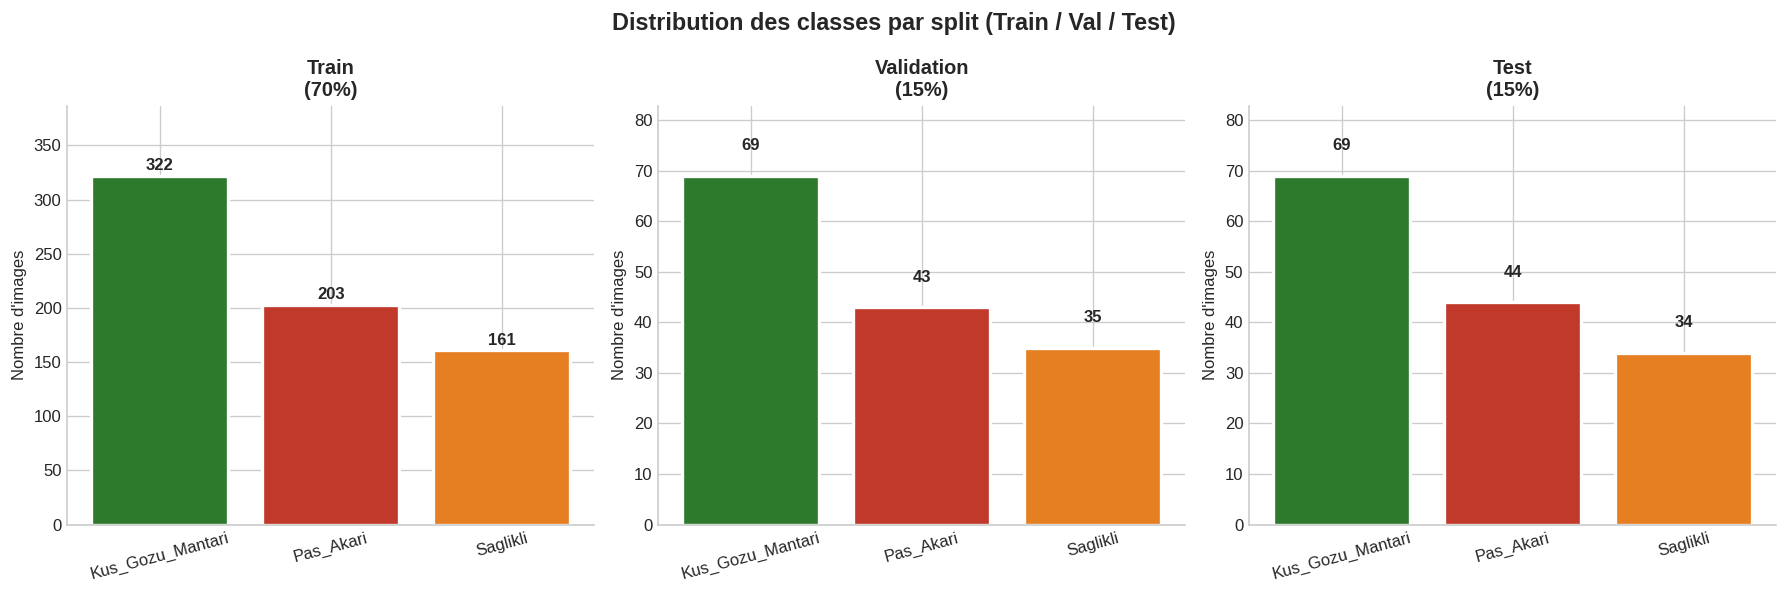

Figure sauvegardée --> /kaggle/working/05_split_distribution.png


In [65]:
# ============================================================
# Cellule 5 — Visualisation du Split
# Graphique de la répartition des classes dans chaque split
# ============================================================

COLORS = ['#2d7a2d', '#c0392b', '#e67e22']

splits = {
    'Train\n(70%)'      : y_train,
    'Validation\n(15%)' : y_val,
    'Test\n(15%)'       : y_test,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Distribution des classes par split (Train / Val / Test)',
    fontsize=14, fontweight='bold'
)

for ax, (split_name, y_split) in zip(axes, splits.items()):
    counts    = np.bincount(y_split)
    cls_names = [idx_to_class[i] for i in range(len(counts))]
    bars = ax.bar(cls_names, counts, color=COLORS, edgecolor='white', linewidth=2)
    for bar, cnt in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(cnt), ha='center', fontsize=10, fontweight='bold'
        )
    ax.set_title(split_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Nombre d\'images')
    ax.set_ylim(0, max(counts) * 1.2)
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/kaggle/working/05_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/05_split_distribution.png')

---
##  Cellule 6 — Data Augmentation

> **Explication :** La Data Augmentation crée artificiellement de nouvelles images en appliquant des transformations aléatoires.
> Elle est appliquée **uniquement sur le Train set**, jamais sur Val et Test.
>
> **Pourquoi c'est crucial ?**
> - Avec seulement 6 961 images, le modèle risque l'**overfitting** (mémorisation)
> - L'augmentation simule des conditions réelles (luminosité variable, angles différents)
> - Chaque époque, le modèle voit des versions légèrement différentes des mêmes images
>
> | Transformation | Valeur | Justification |
> |---|---|---|
> | `rotation_range` | 30° | Feuilles photographiées sous différents angles |
> | `horizontal_flip` | True | Symétrie gauche/droite |
> | `zoom_range` | 0.15 | Différentes distances à la feuille |
> | `brightness_range` | 0.7–1.3 | Variations d'éclairage (soleil, ombre) |
> | `shear_range` | 10° | Légère déformation perspective |

In [66]:
# ============================================================
# Cellule 6 — Data Augmentation
# Transformations aléatoires appliquées uniquement au train set
# ============================================================

# -- Générateur TRAIN : avec augmentation + normalisation ---
# rescale=1./255 : normalise les pixels de [0,255] vers [0,1]
train_datagen = ImageDataGenerator(
    rescale          = 1./255,    # Normalisation : 0-255 → 0-1
    rotation_range   = 30,        # Rotation aléatoire jusqu'à ±30°
    horizontal_flip  = True,      # Miroir horizontal aléatoire
    vertical_flip    = False,     # Pas de miroir vertical (non naturel)
    zoom_range       = 0.15,      # Zoom in/out jusqu'à 15%
    shear_range      = 10,        # Cisaillement jusqu'à 10°
    brightness_range = [0.7, 1.3],# Luminosité entre 70% et 130%
    width_shift_range  = 0.1,     # Décalage horizontal jusqu'à 10%
    height_shift_range = 0.1,     # Décalage vertical jusqu'à 10%
    fill_mode        = 'nearest'  # Remplissage des bords avec pixels voisins
)

# -- Générateur VAL/TEST : uniquement normalisation ----------
# IMPORTANT : pas d'augmentation sur val et test !
val_test_datagen = ImageDataGenerator(
    rescale = 1./255              # Seule la normalisation est appliquée
)

print('Générateurs ImageDataGenerator créés :')
print('  Train DataGen   : normalisation + 8 augmentations')
print('  Val/Test DataGen: normalisation uniquement')
print()
print('Paramètres de normalisation :')
print('  Pixels avant : [0, 255]  (entiers)')
print('  Pixels après : [0.0, 1.0] (flottants)')
print('  Formule      : pixel_norm = pixel_original / 255.0')

Générateurs ImageDataGenerator créés :
  Train DataGen   : normalisation + 8 augmentations
  Val/Test DataGen: normalisation uniquement

Paramètres de normalisation :
  Pixels avant : [0, 255]  (entiers)
  Pixels après : [0.0, 1.0] (flottants)
  Formule      : pixel_norm = pixel_original / 255.0


---
##  Cellule 7 — Visualisation Avant vs Après Augmentation

> **Explication :** On visualise côte à côte une image originale et ses versions augmentées.
> Cela permet de vérifier que les augmentations sont **réalistes et utiles**.
> Les transformations ne doivent pas rendre l'image méconnaissable pour un expert humain.

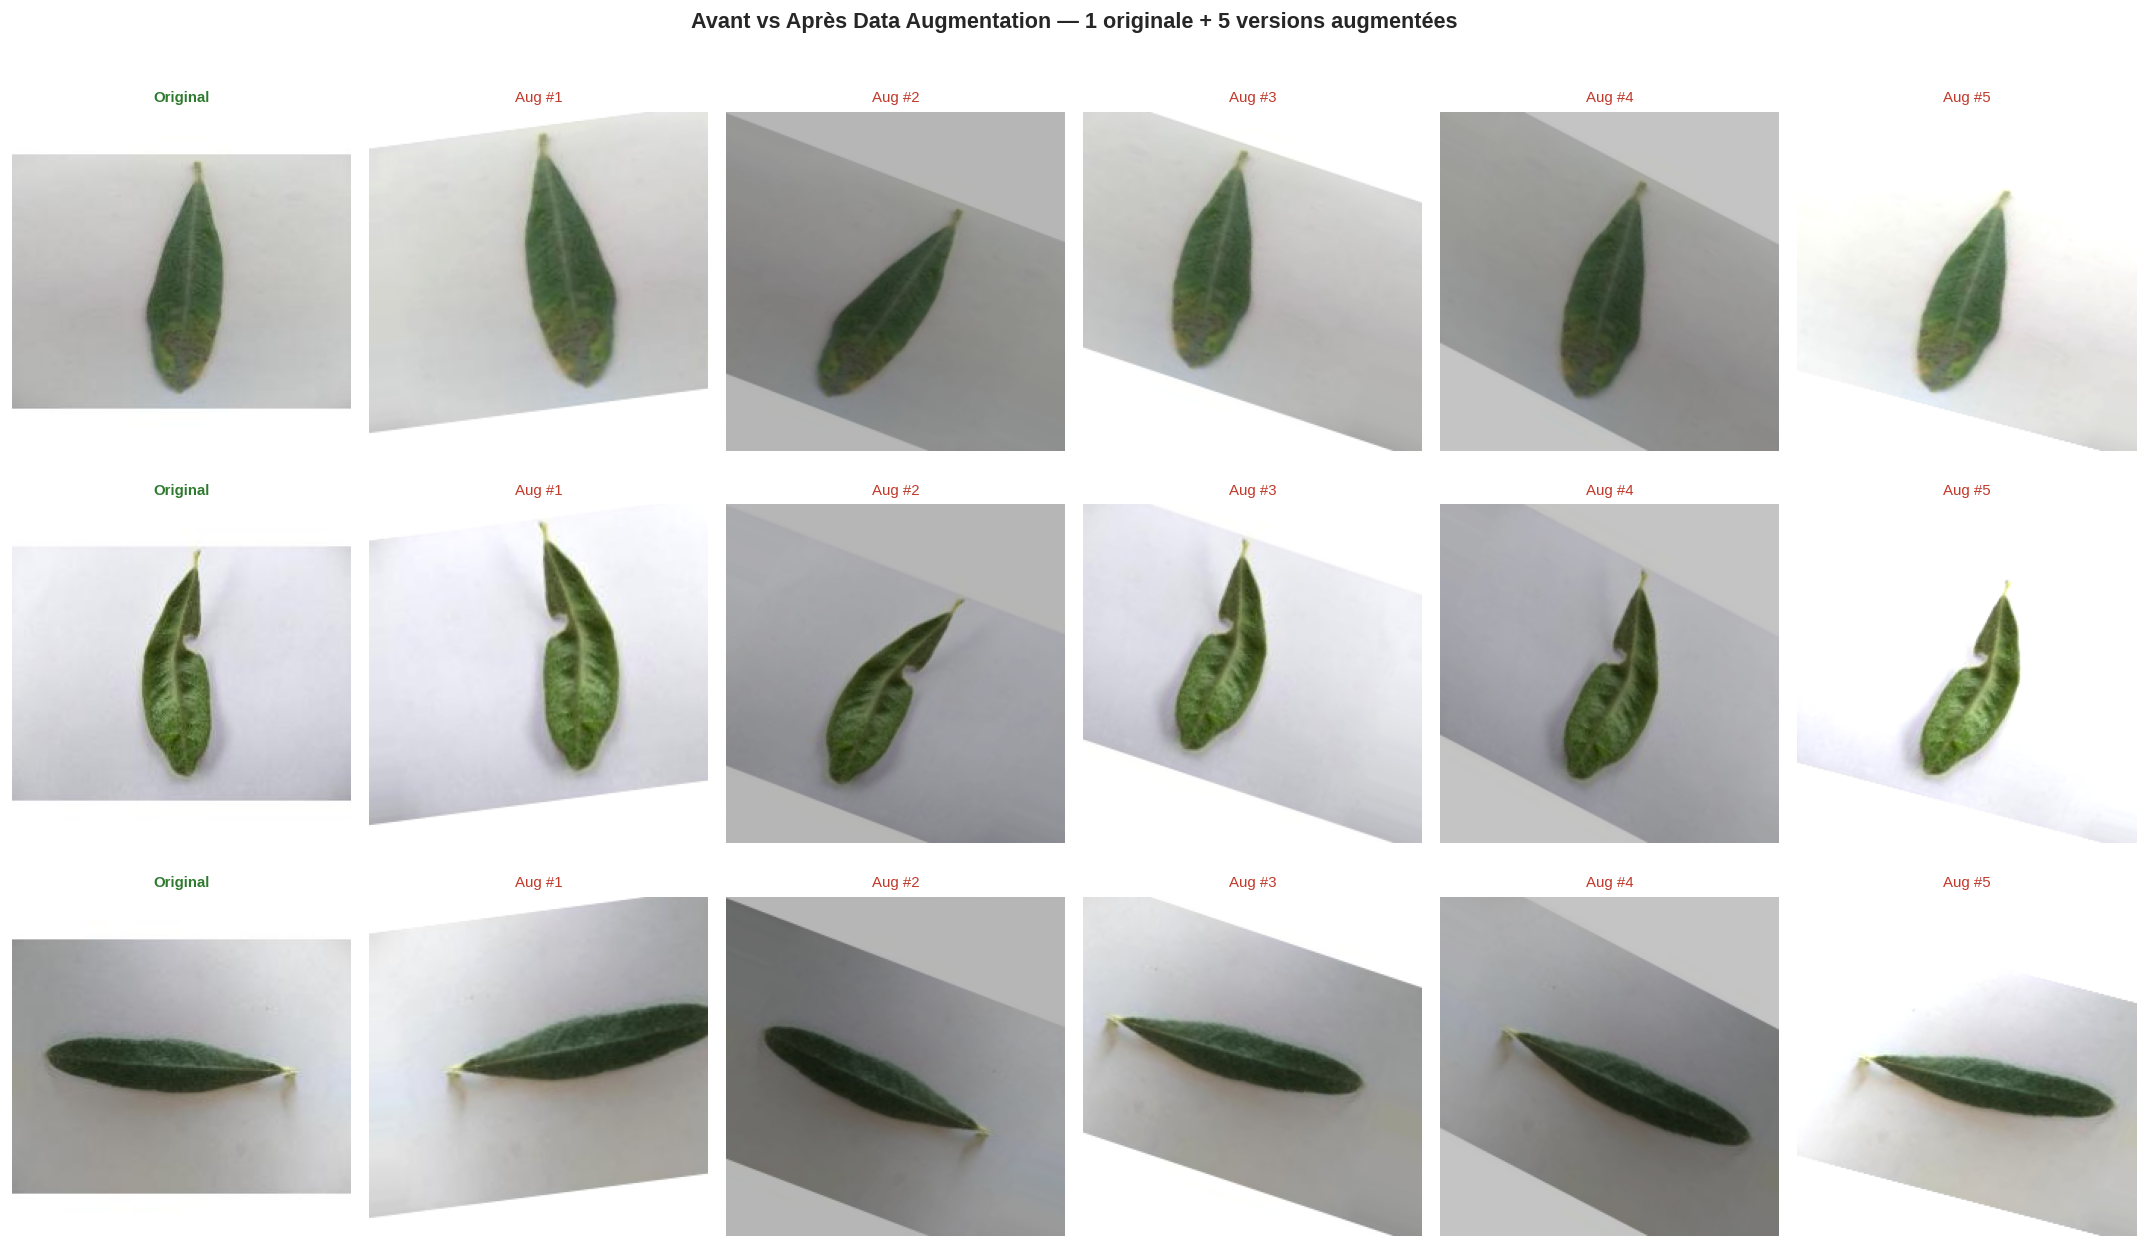

Figure sauvegardée --> /kaggle/working/06_augmentation_demo.png


In [67]:
# ============================================================
# Cellule 7 — Visualisation Avant vs Après Augmentation
# On compare une image originale avec ses versions augmentées
# ============================================================

# Sélection d'une image de chaque classe pour la démo
demo_paths = [X_train[y_train == i][0] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(18, NUM_CLASSES * 3.5))
fig.suptitle(
    'Avant vs Après Data Augmentation — 1 originale + 5 versions augmentées',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (img_path, cls_idx) in enumerate(zip(demo_paths, range(NUM_CLASSES))):
    cls_name = idx_to_class[cls_idx]

    # Lecture de l'image originale
    img_orig = cv2.imread(img_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_orig, (IMG_SIZE, IMG_SIZE))

    # Colonne 0 : image originale (non normalisée pour l'affichage)
    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title('Original', fontsize=9, fontweight='bold', color='#2d7a2d')
    axes[row, 0].axis('off')
    if row == 0 or True:
        axes[row, 0].set_ylabel(cls_name, fontsize=8, rotation=90)

    # Préparation pour le générateur : shape (1, H, W, 3)
    img_array = img_orig.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    # Colonnes 1–5 : versions augmentées
    aug_gen = train_datagen.flow(
        img_array, batch_size=1, seed=42
    )
    for col in range(1, 6):
        aug_img = next(aug_gen)[0]  # Image augmentée
        aug_img = np.clip(aug_img, 0, 1)  # Garder dans [0,1]
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Aug #{col}', fontsize=9, color='#c0392b')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/06_augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/06_augmentation_demo.png')

---
## Cellule 8 — Construction du Pipeline tf.data

> **Explication :** `tf.data` est le pipeline de chargement d'images optimisé de TensorFlow.
> Contrairement à `ImageDataGenerator`, il utilise le **prefetching** et le **parallélisme** pour :
> - Charger les images en avance pendant que le GPU entraîne
> - Réduire le temps d'attente entre les batches
> - Accélérer l'entraînement de **30 à 50%**
>
> **Étapes du pipeline :**
> 1. Lire le fichier image depuis le disque
> 2. Décoder en tensor RGB
> 3. Redimensionner à 224×224
> 4. Normaliser les pixels [0, 1]
> 5. Appliquer l'augmentation (train uniquement)
> 6. Grouper en batches de 32

In [68]:
# ============================================================
# Cellule 8 — Pipeline tf.data Optimisé GPU
# Construction des datasets train / val / test
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

# ── Augmentations appliquées sur des pixels [0, 255] AVANT normalisation ──────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomBrightness(factor=0.10, value_range=(0, 255)),
    tf.keras.layers.RandomContrast(0.10),
], name='data_augmentation')

# ── Fonctions de chargement & prétraitement ───────────────────────────────────
def load_image(path, label):
    """Charge une image et la redimensionne (pixels dans [0, 255])."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)               # [0, 255] float32
    return img, label

def load_and_preprocess(path, label):
    """Charge + normalise uniquement (val / test — sans augmentation)."""
    img, label = load_image(path, label)
    img = img / 255.0                            # normalisation [0, 1]
    return img, label

def load_and_augment(path, label):
    """Charge → augmente sur [0,255] → normalise → clip."""
    img, label = load_image(path, label)
    img = data_augmentation(img, training=True)  # augmentation sur [0, 255]
    img = tf.clip_by_value(img, 0.0, 255.0)      # clip avant normalisation
    img = img / 255.0                            # normalisation [0, 1]
    return img, label

# ── Construction des tf.data.Dataset ─────────────────────────────────────────
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=len(X_train), seed=42)
    .map(load_and_augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print('=' * 55)
print('Pipeline tf.data construit avec succès !')
print('=' * 55)
print(f'  Train batches : {len(train_ds):>5}')
print(f'  Val   batches : {len(val_ds):>5}')
print(f'  Test  batches : {len(test_ds):>5}')
print(f'\n  Ordre correct : chargement [0,255] → augmentation')
print(f'                  → clip [0,255] → normalisation [0,1]')
print(f'  Préfetch      : AUTOTUNE (optimisation GPU)')

Pipeline tf.data construit avec succès !
  Train batches :    22
  Val   batches :     5
  Test  batches :     5

  Ordre correct : chargement [0,255] → augmentation
                  → clip [0,255] → normalisation [0,1]
  Préfetch      : AUTOTUNE (optimisation GPU)


---
##  Cellule 9 — Vérification du Pipeline

> **Explication :** Avant d'entraîner, on vérifie que le pipeline fonctionne correctement :
> - Les images sont bien normalisées entre **0.0 et 1.0**
> - Les shapes des batches sont corrects **(32, 224, 224, 3)**
> - Les labels correspondent bien aux classes attendues
> - On affiche un batch entier pour confirmation visuelle

Vérification du pipeline tf.data
  Shape du batch images  : (32, 224, 224, 3)
    --> (batch_size, H, W, channels) = (32, 224, 224, 3)
  Shape du batch labels  : (32,)
  Type des pixels        : <dtype: 'float32'>
  Valeur min des pixels  : 0.0000 (attendu: ~0.0)
  Valeur max des pixels  : 1.0000 (attendu: ~1.0)
  Labels uniques dans ce batch : [0, 1, 2]

✅ Normalisation : OK (valeurs dans [0.0, 1.0])


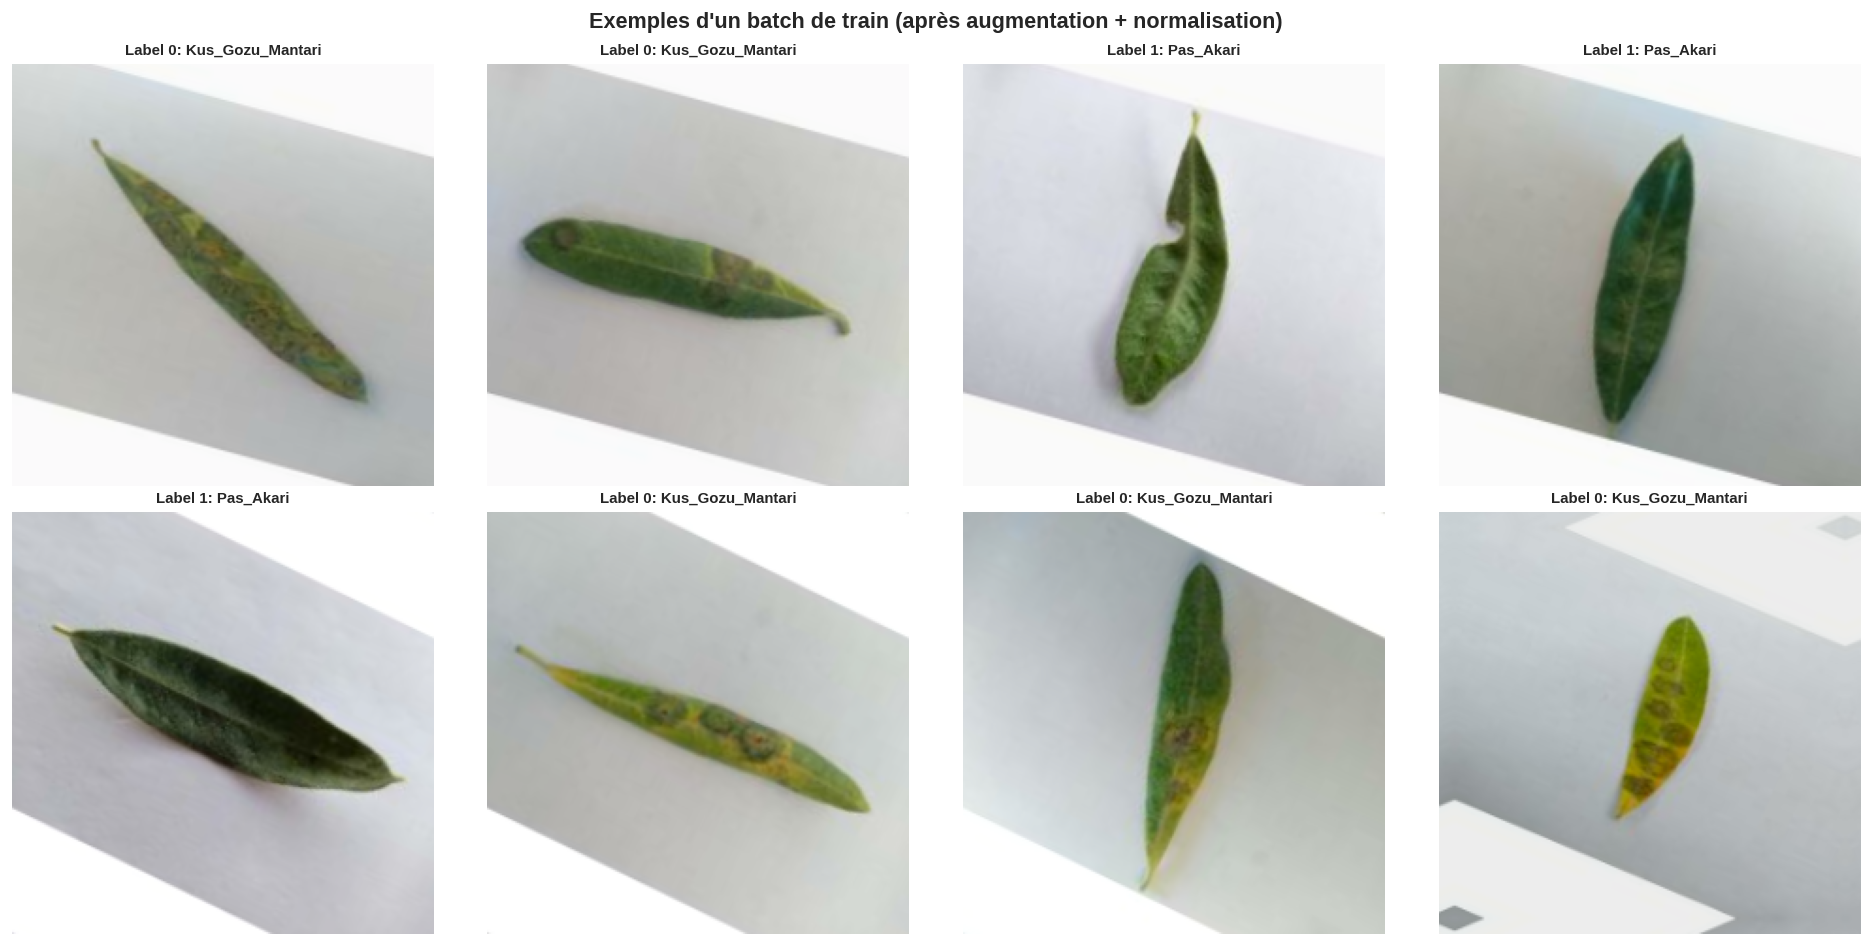

Figure sauvegardée --> /kaggle/working/07_batch_verification.png


In [ ]:
# ============================================================
# Cellule 9 — Vérification du Pipeline
# On vérifie que les batches ont la bonne forme et normalisation
# ============================================================

# Récupération d'un batch du train set pour inspection
sample_imgs, sample_labels = next(iter(train_ds))

print('=' * 55)
print('Vérification du pipeline tf.data')
print('=' * 55)
print(f'  Shape du batch images  : {sample_imgs.shape}')
print(f'    --> (batch_size, H, W, channels) = ({BATCH_SIZE}, {IMG_SIZE}, {IMG_SIZE}, 3)')
print(f'  Shape du batch labels  : {sample_labels.shape}')
print(f'  Type des pixels        : {sample_imgs.dtype}')
print(f'  Valeur min des pixels  : {float(tf.reduce_min(sample_imgs)):.4f} (attendu: ~0.0)')
print(f'  Valeur max des pixels  : {float(tf.reduce_max(sample_imgs)):.4f} (attendu: ~1.0)')
print(f'  Labels uniques dans ce batch : {sorted(set(sample_labels.numpy().tolist()))}')
print('=' * 55)

# Vérification que la normalisation est correcte
assert float(tf.reduce_min(sample_imgs)) >= 0.0, 'Pixels < 0 détectés !'
assert float(tf.reduce_max(sample_imgs)) <= 1.0, 'Pixels > 1 détectés !'
print('\n Normalisation : OK (valeurs dans [0.0, 1.0])')

# Affichage d'un échantillon du batch
n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle(
    f"Exemples d'un batch de train (après augmentation + normalisation)",
    fontsize=13, fontweight='bold'
)
for i in range(n_show):
    img   = sample_imgs[i].numpy()
    label = int(sample_labels[i].numpy())
    axes[i].imshow(img)
    axes[i].set_title(
        f'Label {label}: {idx_to_class[label]}',
        fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/07_batch_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée --> /kaggle/working/07_batch_verification.png')

---
##  Cellule 10 — Sauvegarde de la Configuration Mise à Jour

> **Explication :** On met à jour et sauvegarde `config.json` avec les nouvelles informations
> issues de ce notebook (tailles des splits, mapping classes, etc.).
> Ce fichier sera utilisé dans les notebooks NB3, NB4, NB5 et NB6.

In [70]:
# ============================================================
# Cellule 10 — Sauvegarde de la Configuration Mise à Jour
# On enregistre les nouvelles infos dans config.json
# ============================================================

# Mise à jour de la config avec les résultats de ce notebook
config['n_train']       = int(len(X_train))
config['n_val']         = int(len(X_val))
config['n_test']        = int(len(X_test))
config['class_to_idx']  = class_to_idx
config['idx_to_class']  = {str(k): v for k, v in idx_to_class.items()}
config['augmentation']  = {
    'rotation_range'   : 30,
    'horizontal_flip'  : True,
    'zoom_range'       : 0.15,
    'brightness_range' : [0.7, 1.3],
    'shear_range'      : 10,
    'width_shift'      : 0.1,
    'height_shift'     : 0.1,
}
config['notebook_2_done'] = True

# Sauvegarde
with open('/kaggle/working/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# Sauvegarde des splits (chemins + labels) pour réutilisation
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/X_val.npy',   X_val)
np.save('/kaggle/working/X_test.npy',  X_test)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_val.npy',   y_val)
np.save('/kaggle/working/y_test.npy',  y_test)

print('=' * 55)
print('Configuration et splits sauvegardés !')
print('=' * 55)
print(f'  config.json  --> paramètres du projet')
print(f'  X_train.npy  --> {len(X_train):,} chemins images train')
print(f'  X_val.npy    --> {len(X_val):,} chemins images val')
print(f'  X_test.npy   --> {len(X_test):,} chemins images test')
print(f'  y_train.npy  --> {len(y_train):,} labels train')
print(f'  y_val.npy    --> {len(y_val):,} labels val')
print(f'  y_test.npy   --> {len(y_test):,} labels test')

Configuration et splits sauvegardés !
  config.json  --> paramètres du projet
  X_train.npy  --> 686 chemins images train
  X_val.npy    --> 147 chemins images val
  X_test.npy   --> 147 chemins images test
  y_train.npy  --> 686 labels train
  y_val.npy    --> 147 labels val
  y_test.npy   --> 147 labels test
